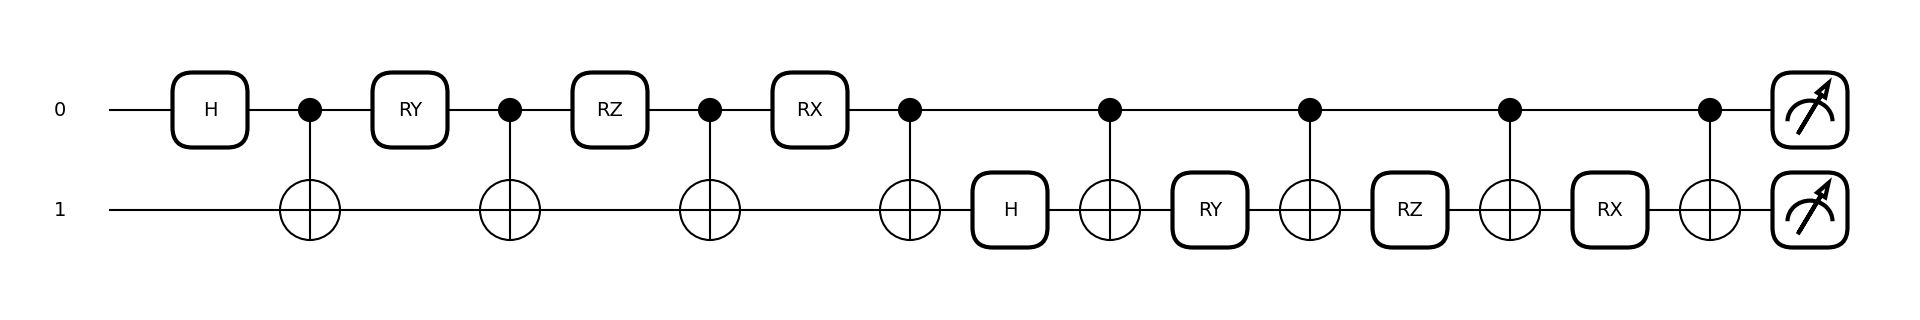

In [2]:
import pennylane as qml
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
# Sample training data
import lightgbm as lgb
import pandas as pd
import numpy as np
import pennylane as qml
from pennylane import numpy as np
from sklearn.svm import SVR

df=pd.read_csv('D:/laptop/ml catalysis/BANDGAP/BAND GAP PREDICTION DT-26-05-2024/DATASET RELATED/2D electronic properties2.csv',encoding='ISO-8859–1')      
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y = df['Band gap ']

# defining target
x=df[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]

# Splitting the dataset into training and test set.  
from sklearn.model_selection import train_test_split  
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.06, random_state=2)  

# Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(x_train)

# Quantum setup
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

# Define quantum feature map
def quantum_feature_map(x):
    for i in range(n_qubits):
        qml.Hadamard(wires=i)
        qml.CNOT(wires=[0, 1])
        qml.RY(np.pi,wires=i)
        qml.CNOT(wires=[0, 1])
        qml.RZ(x[i % len(x)], wires=i)
        qml.CNOT(wires=[0, 1])
        qml.RX(np.pi*1.5, wires=i)
        qml.CNOT(wires=[0, 1])

# Define a quantum node
@qml.qnode(dev)
def circuit(x):
    quantum_feature_map(x)
    return [qml.expval(qml.PauliZ(wires=i)) for i in range(n_qubits)]

# Visualize the quantum circuit for a sample
sample_x = X_train_scaled[0][:n_qubits]  # Take the first training sample, limit to `n_qubits`

# Draw the circuit using matplotlib
fig, ax = qml.draw_mpl(circuit)(sample_x)
plt.show()


In [3]:
# Quantum kernel function
@qml.qnode(dev)
def quantum_kernel(x1, x2):
    quantum_feature_map(x1)
    qml.adjoint(quantum_feature_map)(x2)
    return qml.probs(wires=range(n_qubits))
# Compute the kernel matrix for input data
def compute_kernel_matrix(X):
    n_samples = len(X)
    kernel_matrix = np.zeros((n_samples, n_samples))
    for i in range(n_samples):
        for j in range(n_samples):
            # Directly access the probability value (first element)
            kernel_matrix[i, j] = quantum_kernel(X[i], X[j])[0]
    return kernel_matrix
# Compute the quantum kernel matrix for training
K_train = compute_kernel_matrix(X_train_scaled)

# Train the SVR with a precomputed kernel matrix
svr = SVR(kernel='precomputed', epsilon=0.07491851902055541,C=977,gamma=2.0881963569756823)
svr.fit(K_train, y_train)

# Sample test data

X_test_scaled = scaler.transform(x_test)

# Compute the test kernel matrix (train-test kernel)
K_test = np.zeros((len(X_test_scaled), len(X_train_scaled)))
for i in range(len(X_test_scaled)):
    for j in range(len(X_train_scaled)):
        K_test[i, j] = quantum_kernel(X_test_scaled[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred = svr.predict(K_test)
print("Predicted values:", y_pred)

Predicted values: [1.24526068 0.64667918 1.88692619 1.66798045 4.28170691 3.14844671
 0.83196986 3.41070793 3.34948568 2.85607579 0.6709445  1.61641788
 2.41380249 2.14521136 2.31436789 0.31795649 2.3203742  3.94250832
 1.12234642 2.02511242 1.78852221 2.57851987 1.17668648 1.10873542
 0.57299837 2.24445275 2.84379622 0.77819721 0.63552165 1.92184878
 0.70543662 1.82857593 1.44399791 0.98202564 4.00828819 2.03614467
 1.92430087 2.08920641 0.42114207 1.32918318 1.46753427 3.86761628
 0.37239686 1.62614728 0.5238364  3.14916046 4.4372111  1.1361642
 1.3915515  0.47412495 0.77579908 3.54216033 2.17914989 3.63965035
 1.32691408 2.0885181  0.73475275 1.56998662 1.31906519 1.08119615
 0.76147431 1.04632614 0.40896016 2.75033271 1.56251475 0.81609989
 0.69574927 1.44165485 1.17485697 0.71078752 1.75614422 2.41286819
 0.43004898 0.87226051 0.82067266 2.27559208 2.16770154 3.04593559
 1.07593831 0.82456814 0.74134284 3.49931678 1.08657375 0.8263462
 3.22704008]


train r^2: 0.39973260449762793
train MAE 0.7818886983232953
train RMSE: 1.0959635122095006


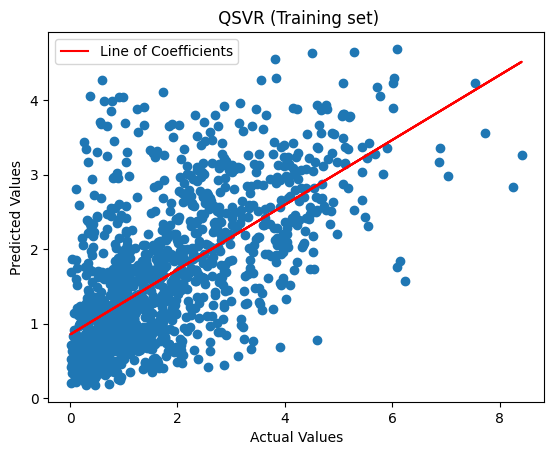

In [4]:
y_predtrain= svr.predict(K_train)
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score
from bayes_opt import BayesianOptimization
import matplotlib.pyplot as plt
print('train r^2:',r2_score(y_train,y_predtrain))
print('train MAE', mean_absolute_error(y_train,y_predtrain))
print('train RMSE:',np.sqrt(mean_squared_error(y_train,y_predtrain)))
# Plot straight line
plt.scatter(y_train,y_predtrain)
coefficients = np.polyfit(y_train,y_predtrain, 1)
line = np.polyval(coefficients, y_train)
plt.plot(y_train, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_train, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_train,y_predtrain)), (-0.2, 20.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_train,y_predtrain)), (-0.2, 18.2))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_train,y_predtrain))), (-0.2, 16.0))
plt.title(" QSVR (Training set)")#title
plt.legend()

Model evaluation - Test Set:
r^2: 0.5397114396270501
RSE 0.7832673270716604
RAE 0.6247672161405055
RMSE: 0.8850239132767319


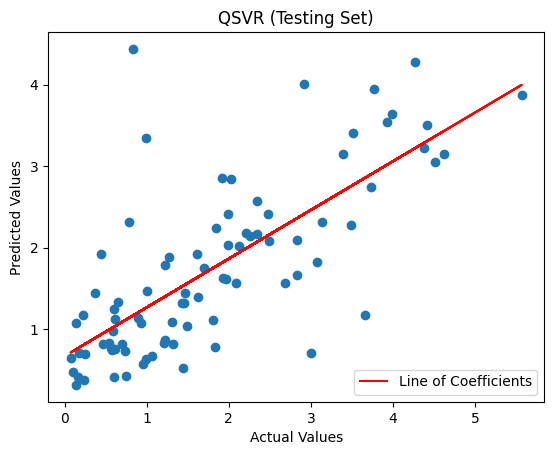

In [5]:
import numpy as np
from sklearn.ensemble import *
from sklearn.metrics import *
from sklearn.model_selection import *
import pandas as pd
## lgbm optimization
import numpy as np
import pandas as pd
from catboost import CatBoostRegressor
from sklearn import ensemble
from sklearn.model_selection import cross_val_score

import matplotlib.pyplot as plt
print("Model evaluation - Test Set:")
print('r^2:',r2_score(y_test, y_pred))
print('RSE', mean_squared_error(y_test, y_pred))
print('RAE', mean_absolute_error(y_test, y_pred))
print('RMSE:',np.sqrt(mean_squared_error(y_test, y_pred)))
# Plot straight line
plt.scatter(y_test, y_pred)
coefficients = np.polyfit(y_test, y_pred, 1)
line = np.polyval(coefficients, y_test)
plt.plot(y_test, line, color='r', label='Line of Coefficients')
# Plot straight line
plt.plot(y_test, line, color='r',)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y_test, y_pred)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y_test, y_pred))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y_test, y_pred)), (-0.2, 13.2))
plt.title("QSVR (Testing Set)")#title
plt.legend()

In [12]:
# Bootstrap predictions
n_bootstrap = 1000

# Ensure y_test and y_test_pred are pandas Series
y_test = pd.Series(y_test)
y_test_pred = pd.Series(y_pred)


r2_scores = []
rmses = []
maes = []

for _ in range(n_bootstrap):
    indices = np.random.randint(0, len(y_test), len(y_test))
    
    y_true_sample = y_test.iloc[indices]
    y_pred_sample = y_test_pred.iloc[indices]
    
    r2_scores.append(r2_score(y_true_sample, y_pred_sample))
    rmses.append(np.sqrt(mean_squared_error(y_true_sample, y_pred_sample)))
    maes.append(mean_absolute_error(y_true_sample, y_pred_sample))

# Confidence intervals
def compute_ci(metric_values):
    return np.percentile(metric_values, 2.5), np.percentile(metric_values, 97.5)

r2_ci = compute_ci(r2_scores)
rmse_ci = compute_ci(rmses)
mae_ci = compute_ci(maes)

print(f"R² 95% CI: {r2_ci}")
print(f"RMSE 95% CI: {rmse_ci}")
print(f"MAE 95% CI: {mae_ci}")


R² 95% CI: (0.22607095128386118, 0.7247230861930797)
RMSE 95% CI: (0.6760143440301496, 1.1231090241098038)
MAE 95% CI: (0.5026928617639188, 0.7703209599708689)


<Figure size 1000x800 with 0 Axes>

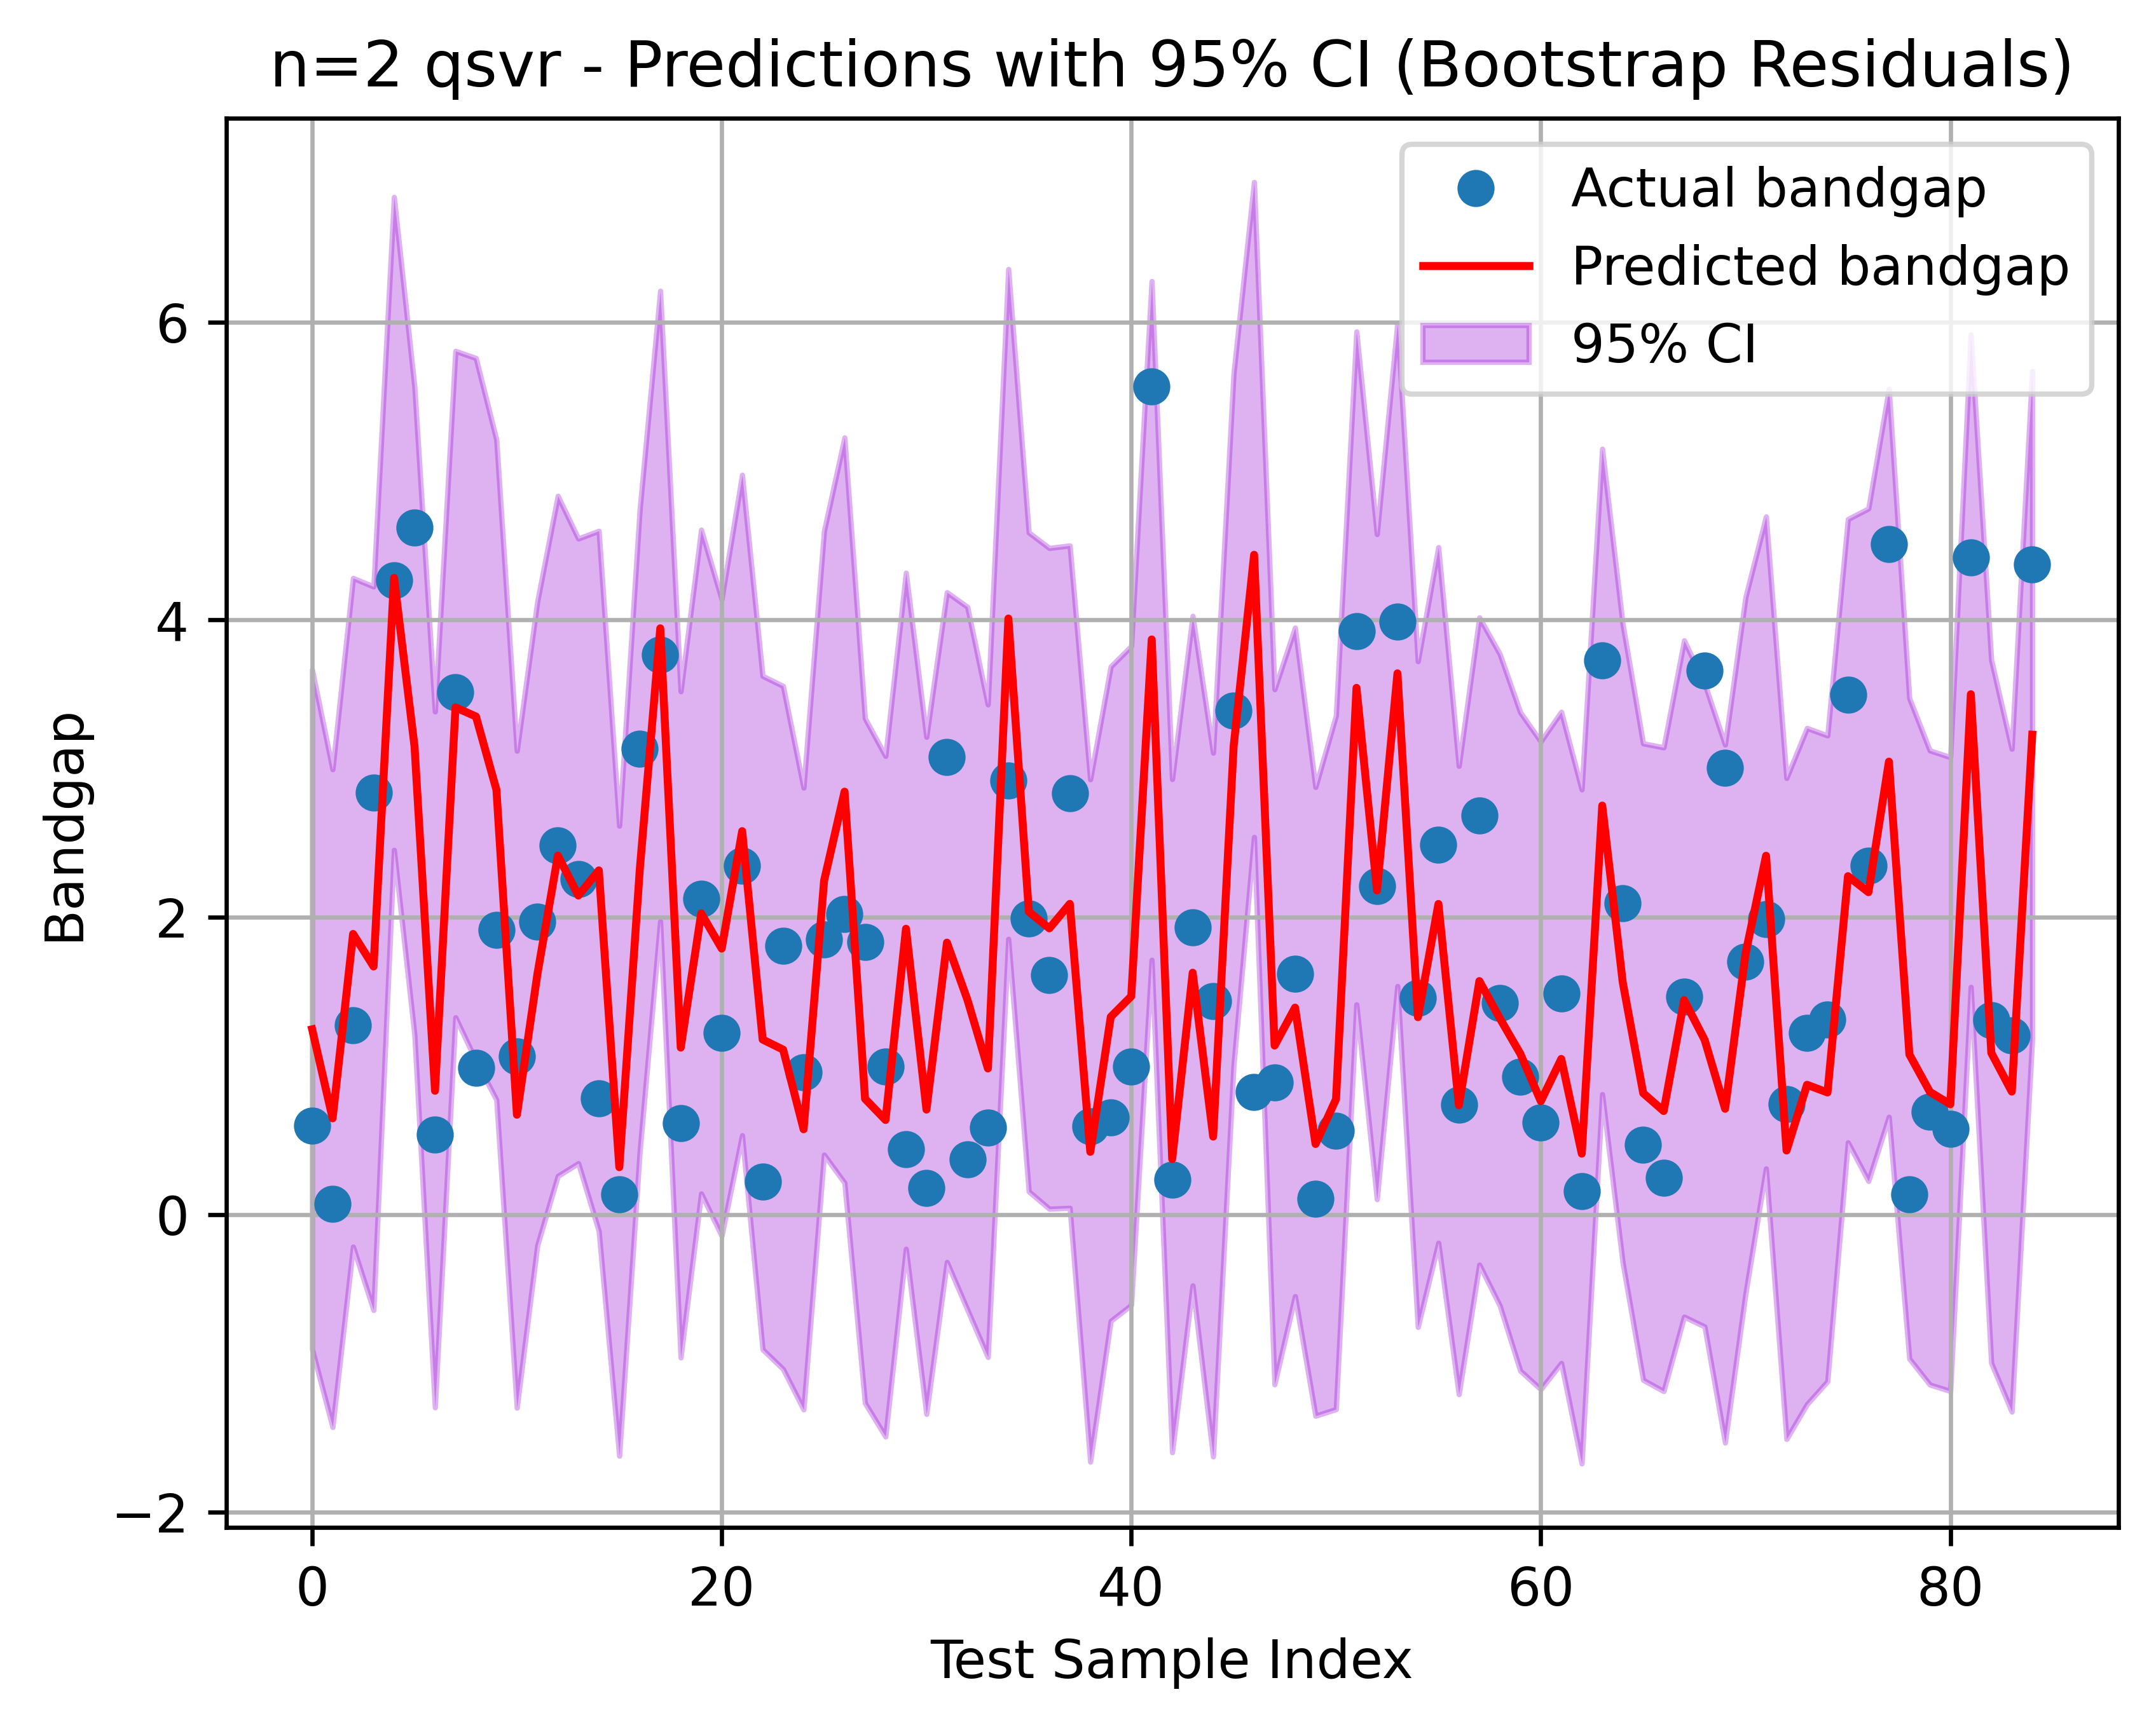

In [13]:
from sklearn.utils import resample

# Calculate residuals from training
residuals = y_train - y_predtrain

# Bootstrap predictions
n_bootstrap = 1000
bootstrap_preds = np.zeros((n_bootstrap, len(x_test)))

for i in range(n_bootstrap):
    sampled_residuals = resample(residuals, replace=True, n_samples=len(x_test))
    bootstrap_preds[i] = y_pred+ sampled_residuals

# Compute 95% confidence intervals
lower_bounds = np.percentile(bootstrap_preds, 2.5, axis=0)
upper_bounds = np.percentile(bootstrap_preds, 97.5, axis=0)

# Plot results
plt.figure(figsize=(10, 8))
plt.figure(dpi=600)
x = np.arange(len(y_test))
plt.plot(x, y_test, 'o', label='Actual bandgap ')
plt.plot(x, y_pred, 'r-', label='Predicted bandgap')
plt.fill_between(x, lower_bounds, upper_bounds,color='darkviolet', alpha=0.3, label='95% CI')
plt.xlabel("Test Sample Index")
plt.ylabel("Bandgap")
plt.title("n=2 qsvr - Predictions with 95% CI (Bootstrap Residuals)",fontsize=12)
plt.legend()
plt.grid(True)
plt.show()


<Figure size 1000x600 with 0 Axes>

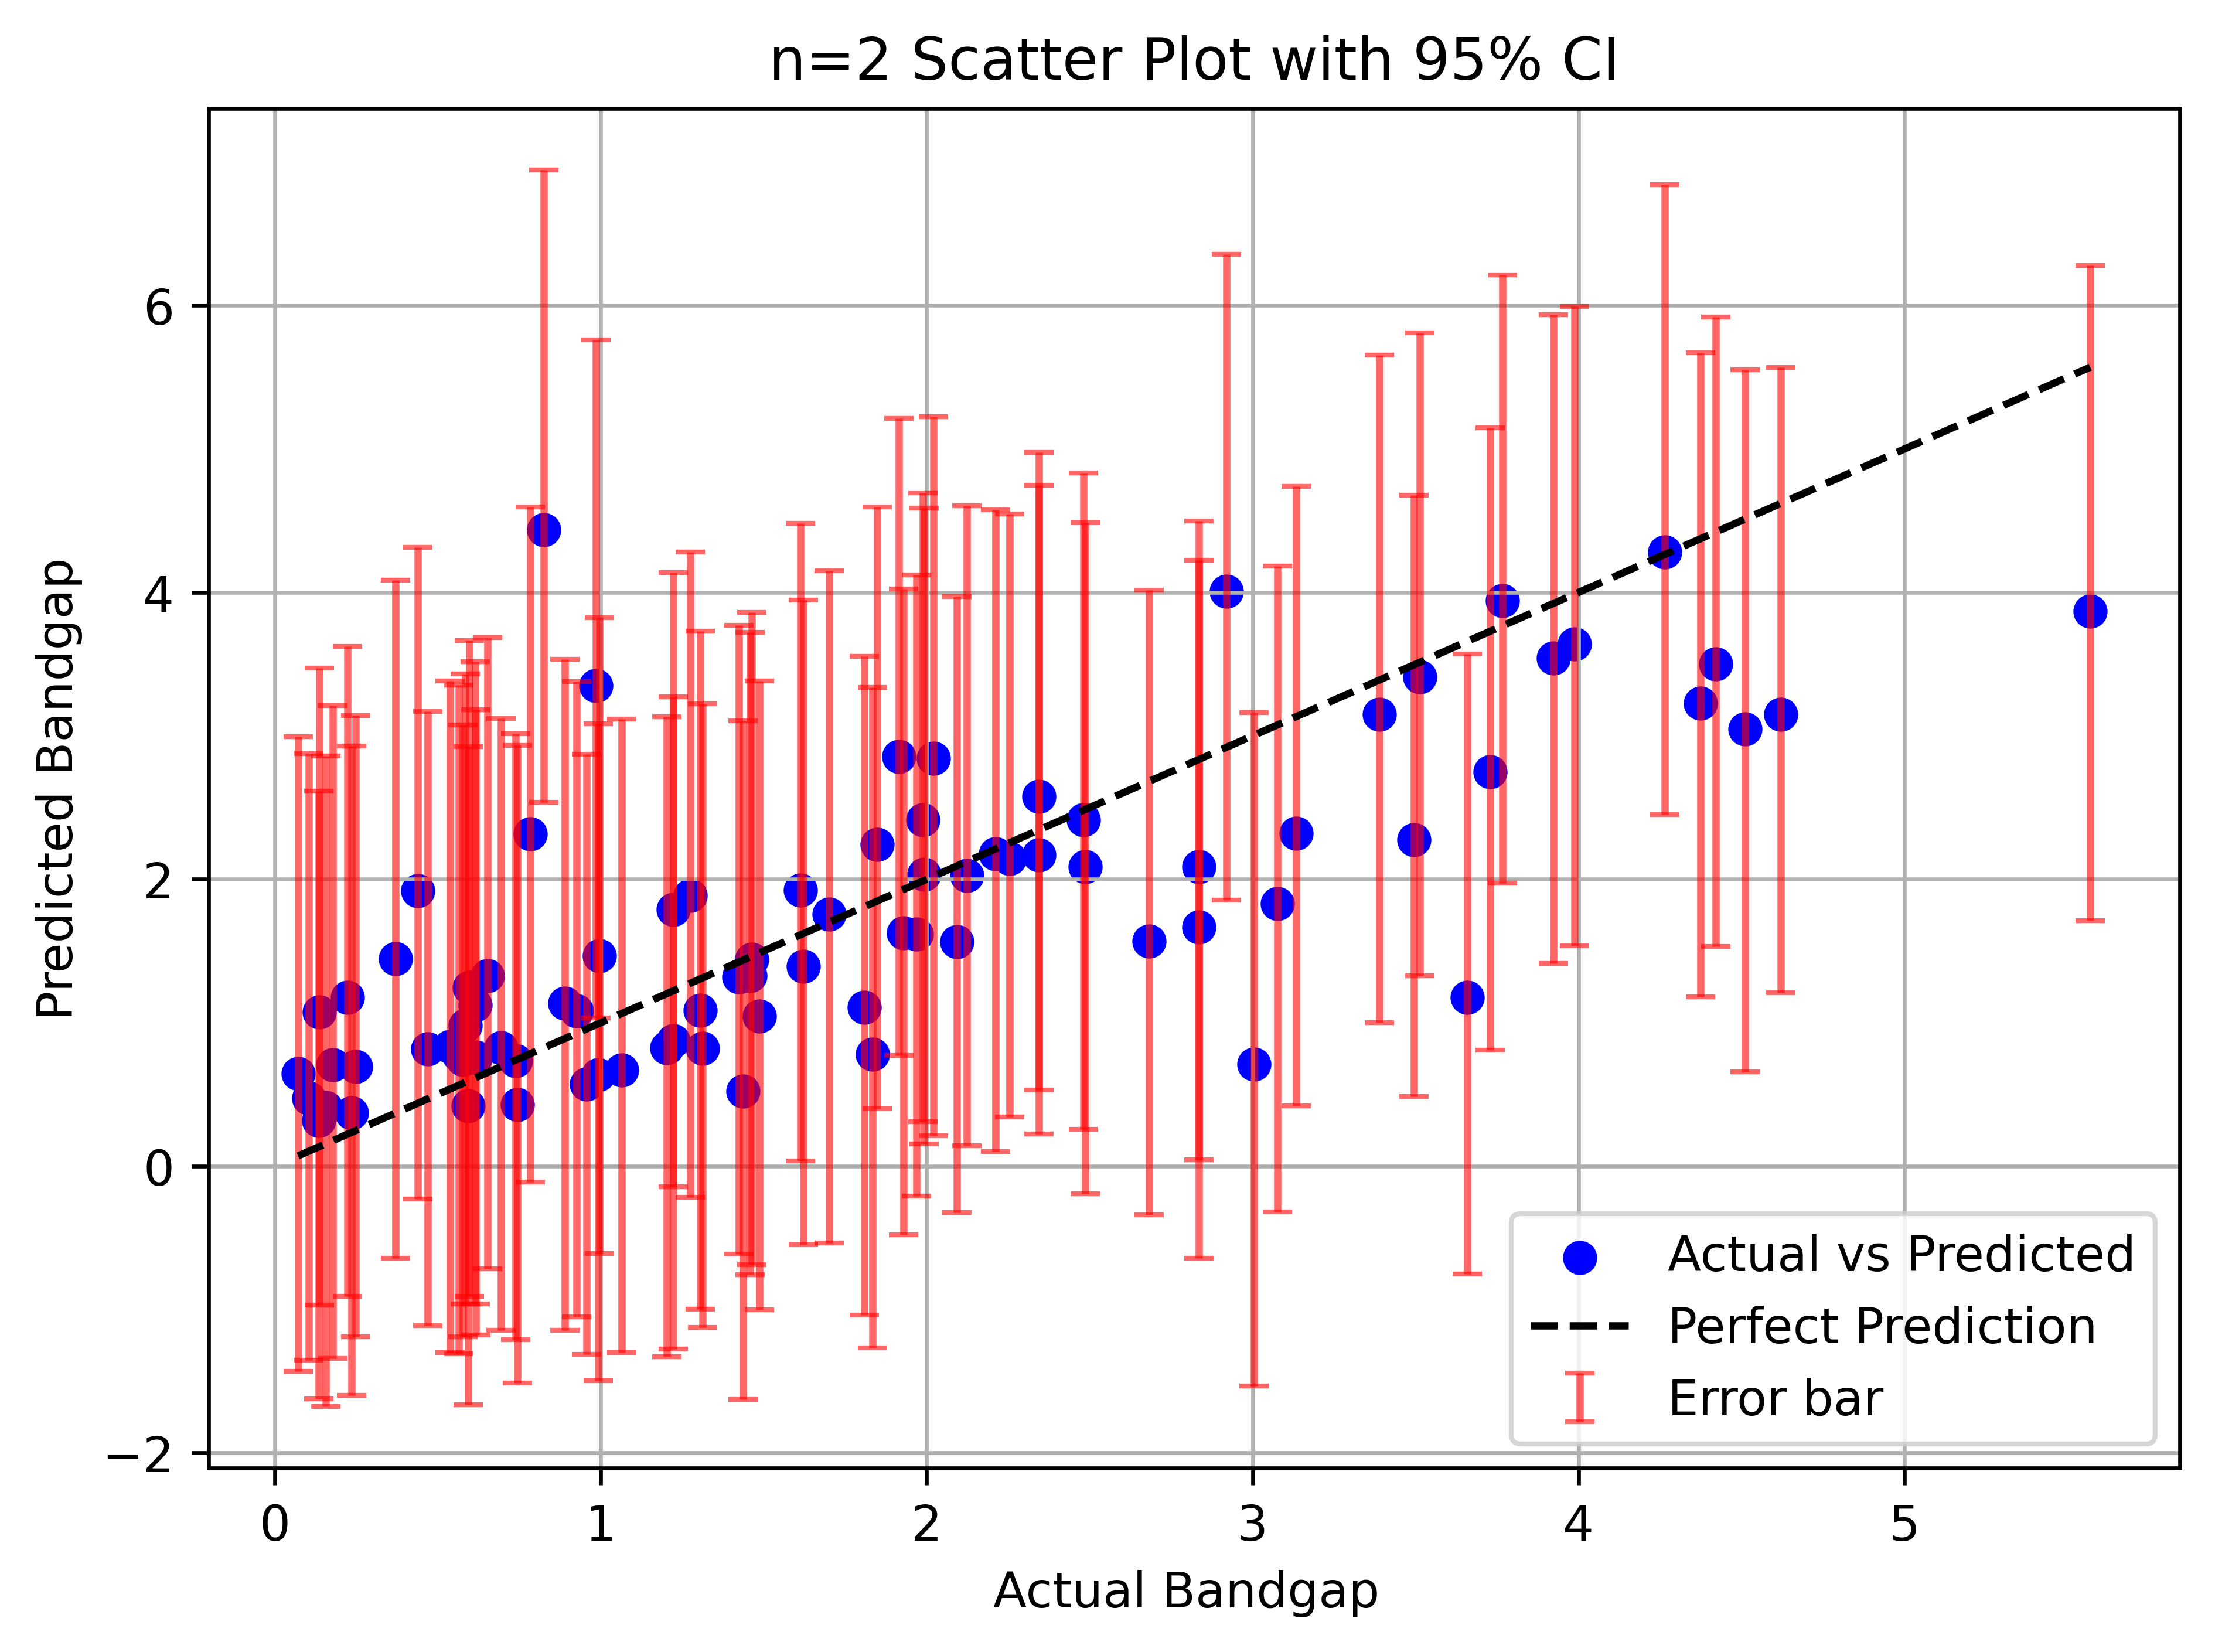

In [33]:
# ==== Scatter Regression Plot ====
plt.figure(figsize=(10, 6))
plt.figure(dpi=600)
plt.scatter(y_test, y_pred, color='blue', label='Actual vs Predicted')

# Plot 95% CI as vertical error bars
plt.errorbar(y_test, y_pred, yerr=[y_pred - lower_bounds, upper_bounds - y_pred], fmt='none', ecolor='red', elinewidth=1.5, capsize=3,alpha=0.6,label='Error bar')
  

# Reference line: perfect prediction
min_val = min(min(y_test), min(y_pred))
max_val = max(max(y_test), max(y_pred))
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Perfect Prediction')

# Labels and legend
plt.xlabel("Actual Bandgap ")
plt.ylabel("Predicted Bandgap")
plt.title("n=2 Scatter Plot with 95% CI")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


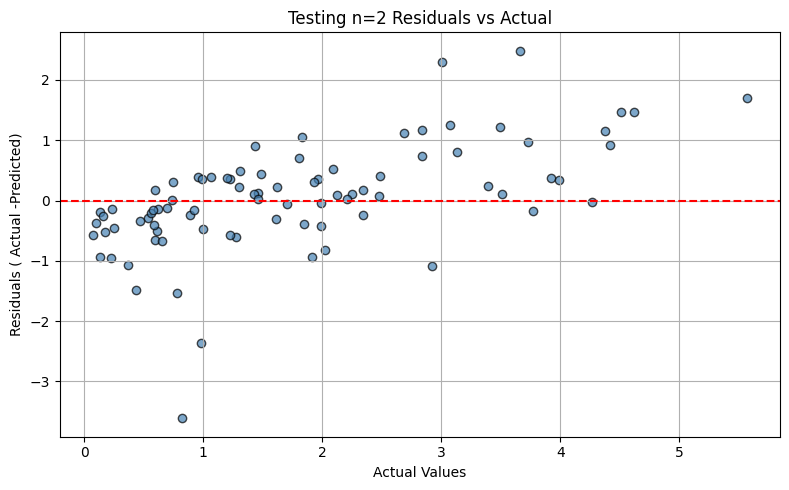

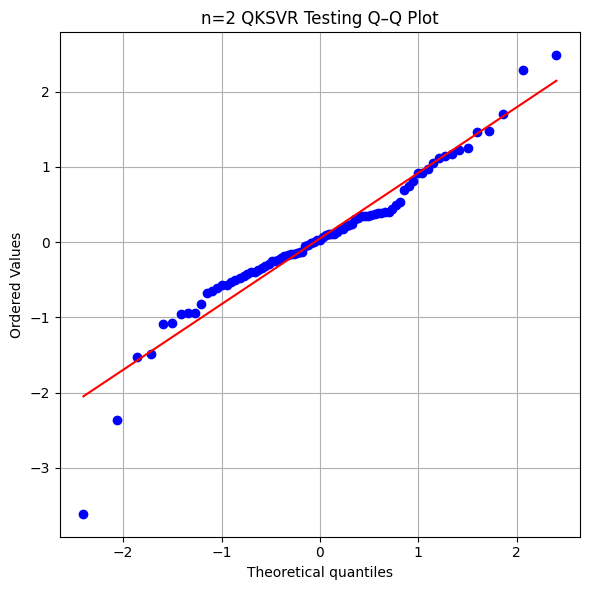

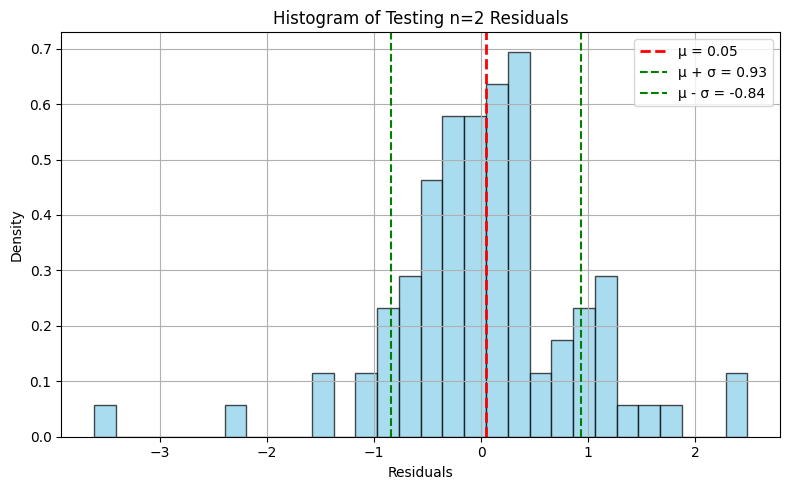

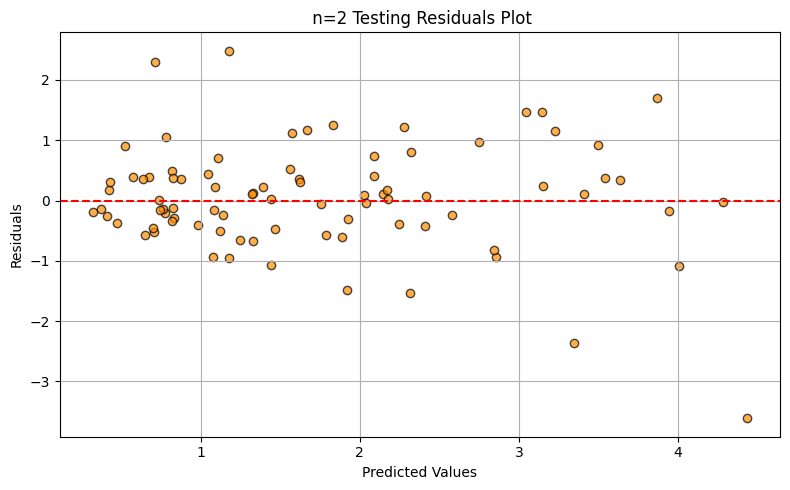

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats

# Assume you already have:
# Y1 = actual values
# predtestextX1 = predicted values from model M1-P1

residuals_test =  y_test-y_pred
mu = np.mean(residuals_test)
sigma = np.std(residuals_test)

# 1. Residuals vs Actual
plt.figure(figsize=(8, 5))
plt.scatter(y_test, residuals_test, alpha=0.7, color='steelblue', edgecolors='k')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Actual Values")
plt.ylabel("Residuals ( Actual -Predicted)")
plt.title("Testing n=2 Residuals vs Actual")
plt.grid(True)
plt.tight_layout()
plt.show()

# 2. Q–Q Plot of Residuals
plt.figure(figsize=(6, 6))
stats.probplot(residuals_test, dist="norm", plot=plt)
plt.title("n=2 QKSVR Testing Q–Q Plot")
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Histogram of Residuals with μ and σ
plt.figure(figsize=(8, 5))
plt.hist(residuals_test, bins=30, color='skyblue', edgecolor='black', alpha=0.7, density=True)
plt.axvline(mu, color='red', linestyle='--', linewidth=2, label=f'μ = {mu:.2f}')
plt.axvline(mu + sigma, color='green', linestyle='--', linewidth=1.5, label=f'μ + σ = {mu + sigma:.2f}')
plt.axvline(mu - sigma, color='green', linestyle='--', linewidth=1.5, label=f'μ - σ = {mu - sigma:.2f}')
plt.title('Histogram of Testing n=2 Residuals')
plt.xlabel('Residuals')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Residuals vs Predicted
plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals_test, alpha=0.7, color='darkorange', edgecolors='k')
plt.axhline(0, color='red', linestyle='--', linewidth=1.5)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title(" n=2 Testing Residuals Plot")
plt.grid(True)
plt.tight_layout()
plt.show()


In [35]:
import numpy as np
import scipy.stats as stats

# Basic Stats
mean_restest= np.mean(residuals_test)
std_restest= np.std(residuals_test)
var_restest = np.var(residuals_test)
min_restest = np.min(residuals_test)
max_restest= np.max(residuals_test)
median_restest= np.median(residuals_test)

# Skewness and Kurtosis
skew_restest= stats.skew(residuals_test)
kurt_restest= stats.kurtosis(residuals_test)  # Fisher (normal = 0)

# Normality Test
shapiro_test= stats.shapiro(residuals_test)



# Print Results
print(f"Mean test: {mean_restest:.4f}")
print(f"Standard Deviation  test: {std_restest:.4f}")
print(f"Variance test: {var_restest:.4f}")
print(f"Min  test: {min_restest:.4f}")
print(f"Max  test: {max_restest:.4f}")
print(f"Median test: {median_restest:.4f}")
print(f"Skewness  test: {skew_restest:.4f}")
print(f"Kurtosis  test: {kurt_restest:.4f}")
print(f"Shapiro-Wilk Test Statistic  test: {shapiro_test.statistic:.4f}, p-value: {shapiro_test.pvalue:.4f}")



Mean test: 0.0473
Standard Deviation  test: 0.8838
Variance test: 0.7810
Min  test: -3.6122
Max  test: 2.4841
Median test: 0.0319
Skewness  test: -0.5382
Kurtosis  test: 3.2054
Shapiro-Wilk Test Statistic  test: 0.9435, p-value: 0.0010


In [21]:
df2=pd.read_csv('D:/quantum all/others/GAN DATASET/repeat 750 data/data clean/validation/50 dataset repeat.csv',encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y2 = df2['Band gap ']

# defining target
x2=df2[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test2= scaler.transform(x2)

# Compute the test kernel matrix (train-test kernel)
K_test2 = np.zeros((len(x_test2), len(X_train_scaled)))
for i in range(len(x_test2)):
    for j in range(len(X_train_scaled)):
        K_test2[i, j] = quantum_kernel(x_test2[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred2 = svr.predict(K_test2)
print("Predicted values:", y_pred2)

Predicted values: [2.74196713 0.48108421 1.05014202 1.35714679 1.79581612 1.34245286
 2.01011119 1.40931339 2.09728651 1.91701924 2.20045911 0.63753894
 3.74833182 0.72161942 3.41768643 0.57429328 1.88927202 3.3294761
 1.19351495 0.8188136  1.40510658 2.67081538 1.50265674 0.47126457
 2.54090707 2.14897157 0.68023657 1.72201291 0.56643957 0.49495162
 0.93245547 0.64629112 1.4016217  1.78140058 0.37076933 1.72855379
 0.69818699 1.66437422 0.71859532 0.71641517 0.79382829 1.94785651
 1.68556909 0.81831871 1.20523366 1.36439833 0.78677395 2.84091418
 2.91128582 0.60255863]


Model evaluation - Test Set:
r^2: 0.305799094947944
MAE 0.7283865867137268
RMSE: 0.9990284531889051


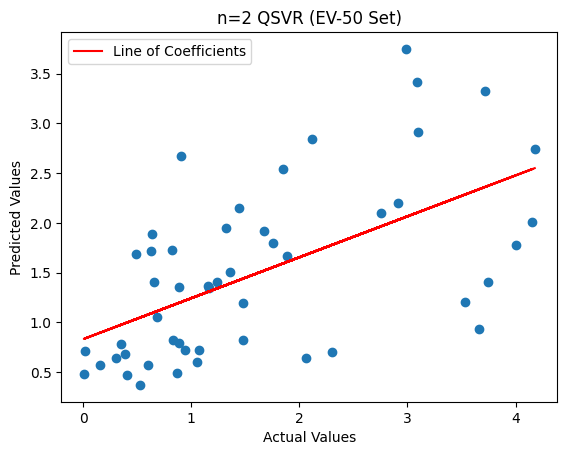

In [22]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y2, y_pred2))
print('MAE', mean_absolute_error(y2, y_pred2))
print('RMSE:',np.sqrt(mean_squared_error(y2, y_pred2)))
# Plot straight line
plt.scatter(y2, y_pred2)
coefficients = np.polyfit(y2, y_pred2, 1)
line = np.polyval(coefficients, y2)
plt.plot(y2, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y2, y_pred2)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y2, y_pred2))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y2, y_pred2)), (-0.2, 13.2))
plt.title("n=2 QSVR (EV-50 Set)")#title
plt.legend()

In [23]:
df3=pd.read_csv('D:/quantum all/others/GAN DATASET/repeat 750 data/data clean/validation/100 dataset repeat.csv',encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y3 = df3['Band gap ']

# defining target
x3=df3[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test3= scaler.transform(x3)

# Compute the test kernel matrix (train-test kernel)
K_test3 = np.zeros((len(x_test3), len(X_train_scaled)))
for i in range(len(x_test3)):
    for j in range(len(X_train_scaled)):
        K_test3[i, j] = quantum_kernel(x_test3[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred3 = svr.predict(K_test3)
print("Predicted values:", y_pred3)

Predicted values: [1.4028124  1.4803735  1.1972357  1.53437779 0.71913109 1.84892185
 1.77636768 1.66914006 2.88734211 2.0911783  1.30162014 1.8587563
 1.08987798 1.16386275 1.9039673  1.5867466  1.29713876 1.5060751
 0.32558139 0.6281915  1.28161838 0.93694145 1.48807013 1.5698691
 0.46707646 0.96752322 2.02172524 1.11054797 0.44506624 0.86571863
 0.61380609 1.33777643 0.49973492 1.67438107 0.67350949 0.41117144
 2.08872522 2.49376081 1.47848497 1.16729372 2.17724302 0.72047031
 2.90110006 0.46388093 1.29047748 0.33248005 2.23893275 1.6151508
 2.16338582 1.71417432 1.95634743 1.74677823 1.52176516 1.60216214
 0.71104853 0.6859475  1.65159422 0.64845674 3.44441921 1.55409811
 0.49091437 0.6957506  1.16405053 2.97661132 3.04216027 0.49475227
 1.3829808  1.49899759 1.93257646 1.1932439  0.41756409 2.33487625
 1.23257496 2.94295473 1.62947495 2.45668033 1.36584313 2.74427297
 2.99398631 0.9187356  0.32661374 0.66719467 0.80560915 0.4814727
 2.49277105 0.85428784 3.84897246 1.45056907 1.76

Model evaluation - Test Set:
r^2: 0.47596341670443665
MAE 0.6964889637241269
RMSE: 0.9698809526451837


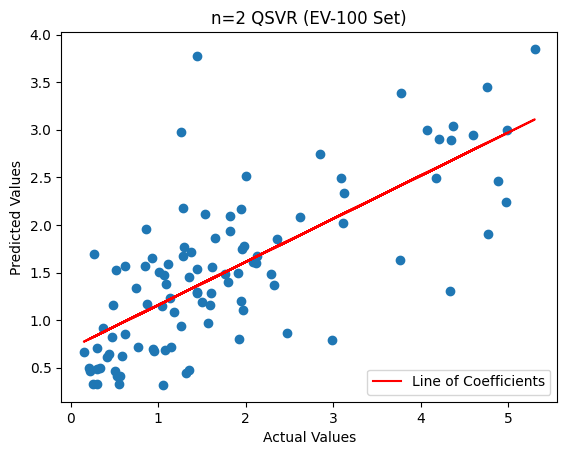

In [24]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y3, y_pred3))
print('MAE', mean_absolute_error(y3, y_pred3))
print('RMSE:',np.sqrt(mean_squared_error(y3, y_pred3)))
# Plot straight line
plt.scatter(y3, y_pred3)
coefficients = np.polyfit(y3, y_pred3, 1)
line = np.polyval(coefficients, y3)
plt.plot(y3, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y3, y_pred3)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y3, y_pred3))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y3, y_pred3)), (-0.2, 13.2))
plt.title("n=2 QSVR (EV-100 Set)")#title
plt.legend()

In [25]:

df4=pd.read_csv('D:/quantum all/others/GAN DATASET/repeat 750 data/data clean/validation/200 dataset repeat.csv',encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y4 = df4['Band gap ']

# defining target
x4=df4[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test4= scaler.transform(x4)

# Compute the test kernel matrix (train-test kernel)
K_test4 = np.zeros((len(x_test4), len(X_train_scaled)))
for i in range(len(x_test4)):
    for j in range(len(X_train_scaled)):
        K_test4[i, j] = quantum_kernel(x_test4[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred4 = svr.predict(K_test4)
print("Predicted values:", y_pred4)

Predicted values: [0.85822654 0.67629219 1.2603545  2.03972857 1.59446626 1.14695104
 1.40432958 0.21289099 1.55580526 0.6359685  0.60114169 1.68591448
 2.43294016 1.18032464 1.2621706  0.38694839 1.44237455 1.72179693
 0.88317286 0.84795939 1.56108886 3.50988515 1.34268389 1.29296109
 0.61828179 1.95871879 3.02390699 3.10724084 0.7641708  1.48527796
 1.34362369 1.5503667  2.14555127 0.69498884 0.53371198 0.29345081
 0.91707047 1.61788778 0.29315426 1.44977438 0.71943637 2.23873963
 3.27288237 3.18975801 2.10956433 0.55882481 1.07312721 1.51695464
 1.32808    0.70483463 2.88744821 1.95709351 0.32177892 1.04427305
 0.55564337 2.49262639 2.30888968 1.85348258 1.21213226 1.3980463
 0.55688997 0.67526728 0.49760259 0.79243448 1.96381821 2.48945454
 1.22126766 0.98823611 2.1566042  1.66116357 1.9203927  3.26434992
 1.17440946 2.50074397 2.37660179 0.87283464 0.70327714 0.99439403
 0.89003478 1.20051226 1.9458     0.56248013 1.49172948 3.17131709
 2.92454156 1.20541285 3.06819214 1.61384628 

Model evaluation - Test Set:
r^2: 0.5361910230090758
MAE 0.670626628796365
RMSE: 0.9335034150653759


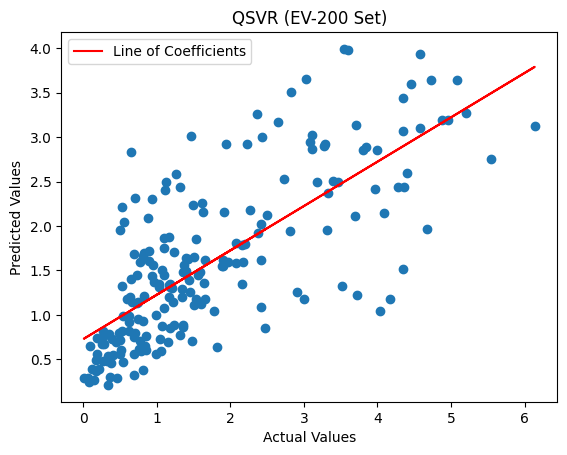

In [26]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y4, y_pred4))
print('MAE', mean_absolute_error(y4, y_pred4))
print('RMSE:',np.sqrt(mean_squared_error(y4, y_pred4)))
# Plot straight line
plt.scatter(y4, y_pred4)
coefficients = np.polyfit(y4, y_pred4, 1)
line = np.polyval(coefficients, y4)
plt.plot(y4, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y4, y_pred4)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y4, y_pred4))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y4, y_pred4)), (-0.2, 13.2))
plt.title("QSVR (EV-200 Set)")#title
plt.legend()

In [27]:
df5=pd.read_csv('D:/quantum all/others/GAN DATASET/repeat 750 data/data clean/validation/400 dataset repeat.csv',encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y5 = df5['Band gap ']

# defining target
x5=df5[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test5= scaler.transform(x5)

# Compute the test kernel matrix (train-test kernel)
K_test5 = np.zeros((len(x_test5), len(X_train_scaled)))
for i in range(len(x_test5)):
    for j in range(len(X_train_scaled)):
        K_test5[i, j] = quantum_kernel(x_test5[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred5 = svr.predict(K_test5)
print("Predicted values:", y_pred5)

Predicted values: [3.43483851 0.74689139 3.71880572 1.22489777 0.60546597 0.51117276
 1.13153973 1.29714748 0.99262247 0.66123826 0.55104162 0.26240497
 0.65788927 0.67813747 3.389655   3.12084784 2.08822564 2.19873859
 2.52832138 0.34688164 2.44469182 1.5804834  1.14022783 1.32317907
 1.78387571 2.34934561 1.76145482 0.65175405 2.19490585 0.95235609
 1.9638238  1.07942356 0.39570882 2.55406311 2.1001632  1.34883603
 2.44535246 4.11365706 1.21162887 0.45846549 2.25245109 1.33165479
 1.99788068 2.02208637 1.46076824 2.46822562 0.60311572 2.23650505
 2.53251542 1.21608003 2.15203399 3.69540382 1.01376358 0.71820703
 0.44923144 1.03194225 2.30361245 1.25827034 1.37017559 1.84402027
 0.44872759 0.5025632  2.08593546 1.10161278 1.14567419 0.9468233
 0.51961779 1.09191916 1.2369779  0.87400532 1.45939325 1.3742488
 1.20457111 1.30107614 1.86626461 2.75104522 1.94163275 1.83567779
 2.39585888 0.5961227  1.01584663 0.55506219 0.72810854 1.49557423
 1.79182163 4.03753546 1.83095723 1.20815248 1

Model evaluation - Test Set:
r^2: 0.5150387952304314
MAE 0.6754244577197767
RMSE: 0.9421618219543069


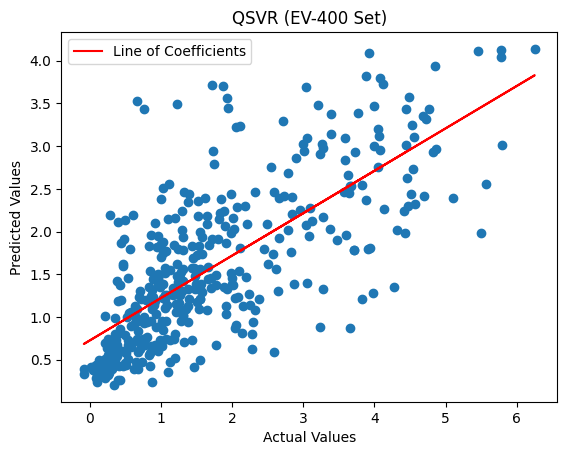

In [28]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y5, y_pred5))
print('MAE', mean_absolute_error(y5, y_pred5))
print('RMSE:',np.sqrt(mean_squared_error(y5, y_pred5)))
# Plot straight line
plt.scatter(y5, y_pred5)
coefficients = np.polyfit(y5, y_pred5, 1)
line = np.polyval(coefficients, y5)
plt.plot(y5, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y5, y_pred5)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y5, y_pred5))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y5, y_pred5)), (-0.2, 13.2))
plt.title("QSVR (EV-400 Set)")#title
plt.legend()

In [29]:
df6=pd.read_csv('D:/quantum all/others/GAN DATASET/repeat 750 data/data clean/validation/750 clean data repeat .csv',encoding='ISO-8859–1')     
# Suppose 'feature_to_drop' is the feature you want to drop from input features (X)
y6 = df6['Band gap ']

# defining target
x6=df6[[ 'Val. band maximum ', 'Mass ','n-spins ','Number of atoms ','Fermi level ', 'Energy above convex hull ','Cond. band minimum ','Area of unit-cell','Heat of formation ']]
x_test6=  scaler.transform(x6)

# Compute the test kernel matrix (train-test kernel)
K_test6 = np.zeros((len(x_test6), len(X_train_scaled)))
for i in range(len(x_test6)):
    for j in range(len(X_train_scaled)):
        K_test6[i, j] = quantum_kernel(x_test6[i], X_train_scaled[j])[0]

# Predict using the trained model
y_pred6 = svr.predict(K_test6)
print("Predicted values:", y_pred6)

Predicted values: [2.74196713 0.48108421 1.05014202 1.35714679 1.79581612 1.34245286
 2.01011119 1.40931339 2.09728651 1.91701924 2.20045911 0.63753894
 3.74833182 0.72161942 3.41768643 0.57429328 1.88927202 3.3294761
 1.19351495 0.8188136  1.40510658 2.67081538 1.50265674 0.47126457
 2.54090707 2.14897157 0.68023657 1.72201291 0.56643957 0.49495162
 0.93245547 0.64629112 1.4016217  1.78140058 0.37076933 1.72855379
 0.69818699 1.66437422 0.71859532 0.71641517 0.79382829 1.94785651
 1.68556909 0.81831871 1.20523366 1.36439833 0.78677395 2.84091418
 2.91128582 0.60255863 1.4028124  1.4803735  1.1972357  1.53437779
 0.71913109 1.84892185 1.77636768 1.66914006 2.88734211 2.0911783
 1.30162014 1.8587563  1.08987798 1.16386275 1.9039673  1.5867466
 1.29713876 1.5060751  0.32558139 0.6281915  1.28161838 0.93694145
 1.48807013 1.5698691  0.46707646 0.96752322 2.02172524 1.11054797
 0.44506624 0.86571863 0.61380609 1.33777643 0.49973492 1.67438107
 0.67350949 0.41117144 2.08872522 2.49376081 1.

Model evaluation - Test Set:
r^2: 0.5050887178906496
MAE 0.6804844460737103
RMSE: 0.9475041484035773


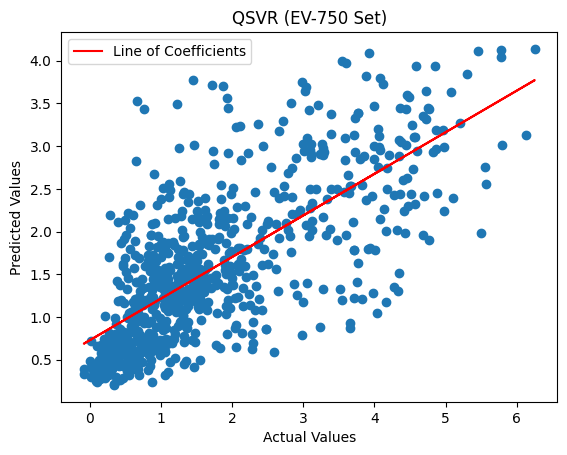

In [30]:

print("Model evaluation - Test Set:")
print('r^2:',r2_score(y6, y_pred6))
print('MAE', mean_absolute_error(y6, y_pred6))
print('RMSE:',np.sqrt(mean_squared_error(y6, y_pred6)))
# Plot straight line
plt.scatter(y6, y_pred6)
coefficients = np.polyfit(y6, y_pred6, 1)
line = np.polyval(coefficients, y6)
plt.plot(y6, line, color='r', label='Line of Coefficients')

plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.annotate("R^2 = {:.3f}".format(r2_score(y6, y_pred6)), (-0.2, 16.0))
plt.annotate("RMSE= {:.3f}".format(np.sqrt(mean_squared_error(y6, y_pred6))), (-0.2, 15.0))
plt.annotate("MAE= {:.3f}".format(mean_absolute_error(y6, y_pred6)), (-0.2, 13.2))
plt.title("QSVR (EV-750 Set)")#title
plt.legend()